# Increased CNN Model capacity with Data Augmentation (Upgraded Model)

Following our observation of data augmentation improving the validation metrics by introducing better generalization to the model, this is a point where we may experiment with a more powerful CNN architecture. Although the model will still have four convolutional layers, each followed by 2×2 max pooling, and pass through two fully connected layers, we will now increase the number of channels that go through each convolutional layer. This upgrade will let the network learn more complex and detailed features at each layer, improving its ability to recognize specific patterns and distinct objects in the data. The main trade-off, besides increased computational cost, would be the risk of overfitting, but since we introduced and saw the impact of data augmentation in the previous model, this may be the ideal time to increase model capacity. In `src/models.py`, there is a breakdown of the number of channels and image size through all steps of the model. Finally, this model will be referred to as the **Upgraded Model** from now on.

## Load Data

In [1]:
# Jupyter opens notebooks from the /waste-classification/notebooks directory, so we move to the project root.
%cd ..

/Users/rodrigomattos/Desktop/projects/waste-classification


In [2]:
from src.data import get_data, get_transform, get_transform_aug, get_datasets, get_dataloaders
import torch

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [4]:
transform = get_transform()
transform_aug = get_transform_aug()
dataset = get_data(transform)
dataset

Dataset ImageFolder
    Number of datapoints: 4817
    Root location: data/cnn_waste_classification
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [5]:
train_data, val_data, test_data = get_datasets(transform_aug, transform)

In [6]:
train_loader, val_loader, test_loader = get_dataloaders(train_data, val_data, test_data)

## Creating Model

In [7]:
from src.models import UpgradedConvolutionalNetwork

In [8]:
upgraded_model = UpgradedConvolutionalNetwork()
upgraded_model.load_state_dict(torch.load('models/03_upgraded_aug_sgd_momentum50.pth'))

<All keys matched successfully>

In [9]:
upgraded_model.to(device)

UpgradedConvolutionalNetwork(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=18432, out_features=90, bias=True)
  (fc2): Linear(in_features=90, out_features=9, bias=True)
)

## Evaluating Model

In [10]:
from src.evaluation import evaluate_model, create_confusion_matrix, inspecting_images

### - Validation Loss and Accuracy

In [11]:
loss, accuracy, all_labels, all_predictions = evaluate_model(upgraded_model, val_loader)

In [12]:
print(f"Validation Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f}%")

Validation Loss: 1.0630
Accuracy: 62.10%


Given the validation loss of 1.0630 and accuracy of 62.10%, we can see a significant improvement in both validation metrics with the Upgraded Model compared to the Augmented Model. The newer model was able to fit the data better, with stronger confidence and a higher number of correct predictions. This suggests that the increased model capacity was beneficial after introducing data augmentation, allowing the model to learn more complex features without significantly compromising its generalization.

### - Confusion Matrix

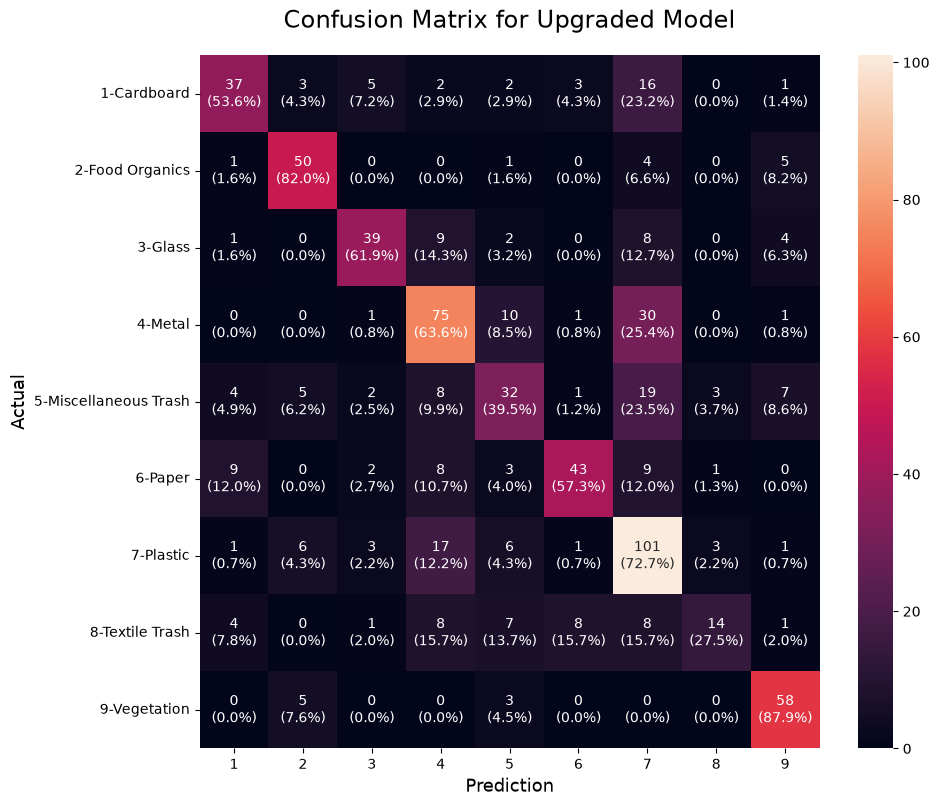

In [13]:
create_confusion_matrix(all_labels, all_predictions, dataset.classes, title="Confusion Matrix for Upgraded Model")

**Confusion Matrix Insights:**

. More than half of the classes achieved at least 60% accuracy.

. The Miscellaneous Trash and Textile Trash classes again achieved low accuracy (39.5% and 27.5%, respectively), but this is already a noticeable increase from the previous model.

. The Upgraded Model seemed to predict fewer objects as Plastic compared to the Augmented Model, probably because of the better feature detection introduced by this more complex model.

. Food Organics and Vegetation managed to achieve an accuracy over 80%, which indicates that the model is good at distinguishing more natural objects from more artificial ones.

### - Inspecting misclassified images

Found 30 4-Metal → 7-Plastic


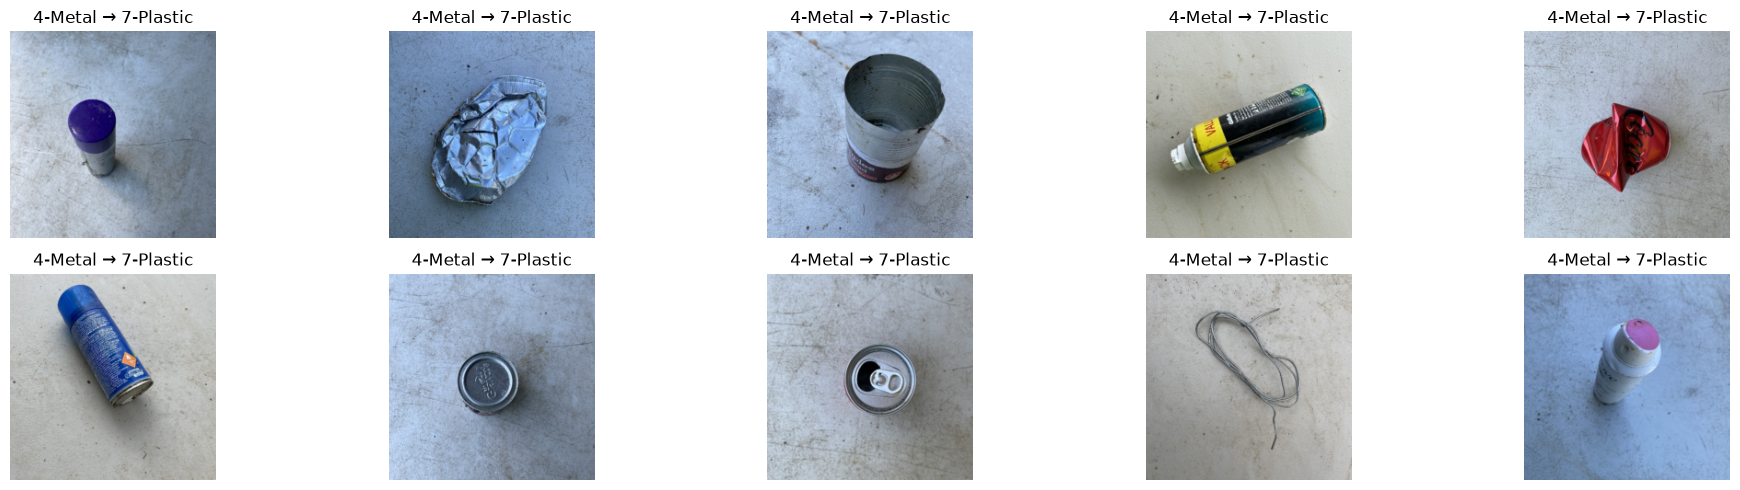

In [14]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "4-Metal", "7-Plastic") # 30 errors

Found 19 5-Miscellaneous Trash → 7-Plastic


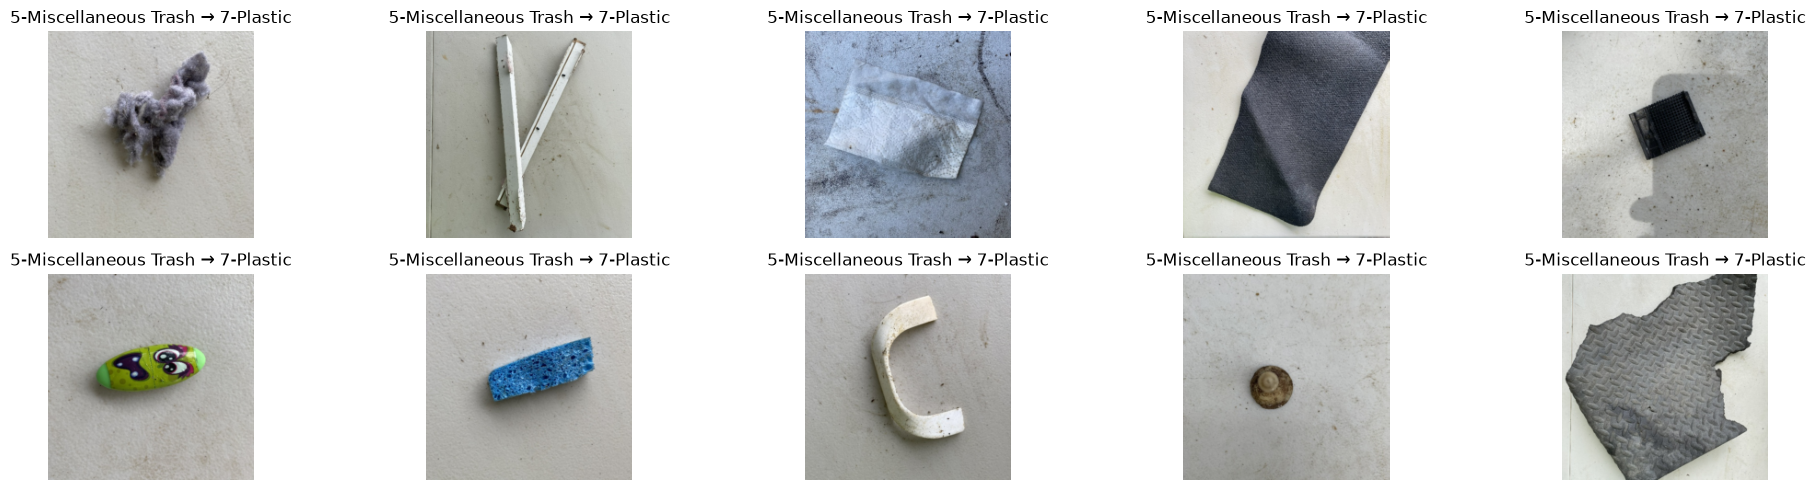

In [15]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "5-Miscellaneous Trash", "7-Plastic") # 19 errors

Found 10 4-Metal → 5-Miscellaneous Trash


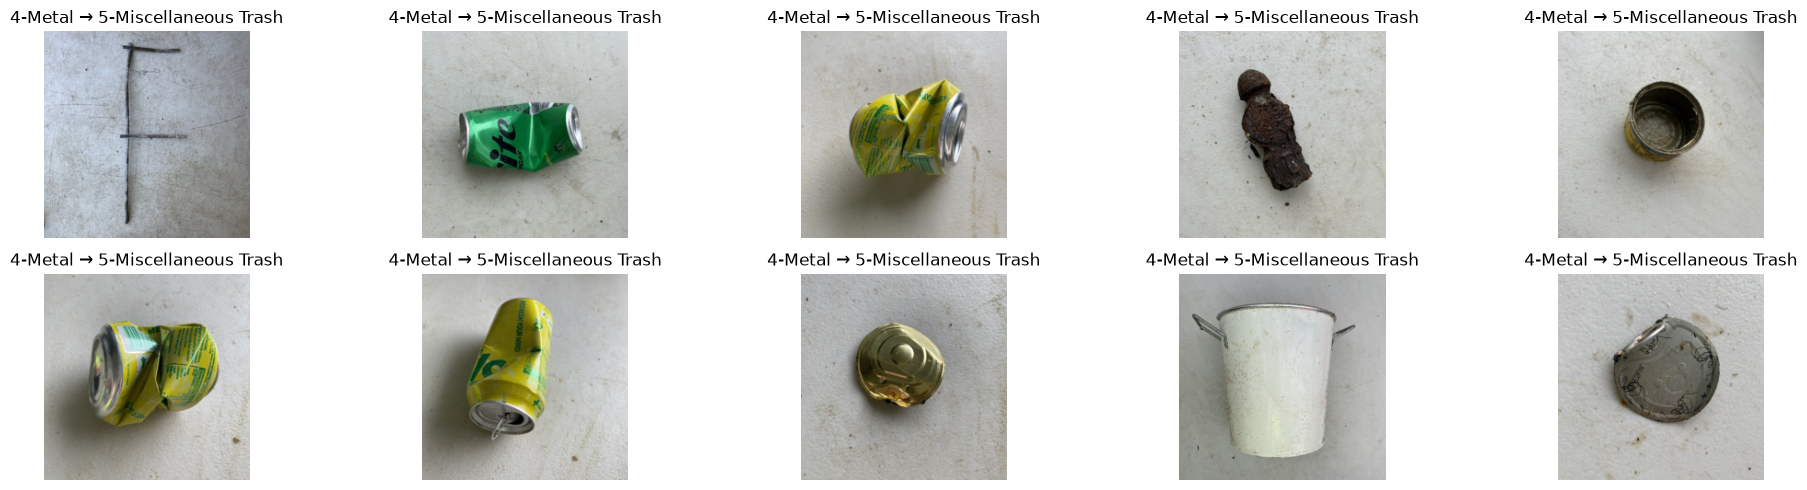

In [16]:
inspecting_images(dataset, val_data, all_labels, all_predictions, "4-Metal", "5-Miscellaneous Trash") # 10 errors

**Misclassified Images Insights:**  

. Again, many different types of objects were misclassified as Plastic, showing a tendency of the model to classify many objects as Plastic.

. The model misclassified a few clear Metal objects, such as metal cans or a metal bin, as Miscellaneous Trash.